## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error


Set a random variable for repreducability of the results


In [2]:
random_var=2026

## 2. Read Data

Define a variable to where files are saved on the pc

In [3]:
path_to_files = "https://raw.github.com/jan-source/course_business_analytics_students/main/teaching_cases/case_2_bi_report/data"

### Load Transactions

In [4]:
transactions_part_a = pd.read_excel(f'{path_to_files}/procurement_transactions_part_a.xlsx')

Load part B of the transactions dataset

In [5]:
transactions_part_b = pd.read_excel(f'{path_to_files}/procurement_transactions_part_b.xlsx')

Merge both transaction parts on the 'id' column

In [6]:
transactions = pd.merge(transactions_part_a, transactions_part_b, on='id', how='left')

Show the first rows of the merged transactions dataset

In [7]:
transactions.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id,order_date,requested_date,received_date,quantity,price
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3,2020-06-05,2020-06-15,2020-06-20 07:00:00,750,3.742660
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad,2023-12-28,2024-01-09,2024-01-10 03:00:00,750,7.382834
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3,2020-09-07,2020-09-26,2020-09-30 04:00:00,250,5.038926
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b,2023-03-30,2023-04-17,2023-04-16 01:00:00,500,43.626411
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa,2020-03-29,2020-04-17,2020-04-16 07:00:00,250,30.163969


<div style="background-color:#fff3bf; border-left:6px solid #f08c00; padding:10px 12px; border-radius:4px;color:black">
<strong>Important:</strong> Currently Python will use 00:00:00 for each requested date, resulting in more late deliveries than in the dashboard, if we want to avoid this we could convert the timestampe to a date:
</div>

Create the target variable: a transaction difference between received and requested date

In [8]:
transactions['days_late'] = (pd.to_datetime(transactions['received_date']) - pd.to_datetime(transactions['requested_date'])).dt.days

Show the proportion (share) of late transactions

In [9]:
transactions['days_late'].mean()

np.float64(-0.78312)

Histogram of days late

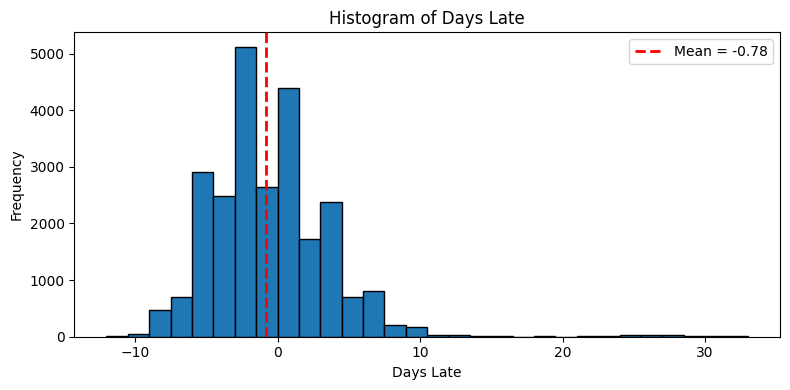

In [10]:

x = transactions['days_late'].dropna()
m = x.mean()

plt.figure(figsize=(8, 4))
plt.hist(x, bins=30, edgecolor='black')
plt.axvline(m, color='red', linestyle='--', linewidth=2, label=f"Mean = {m:.2f}")
plt.title('Histogram of Days Late')
plt.xlabel('Days Late')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

Show the first rows of transactions including the new late flag

In [11]:
transactions.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id,order_date,requested_date,received_date,quantity,price,days_late
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3,2020-06-05,2020-06-15,2020-06-20 07:00:00,750,3.742660,5
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad,2023-12-28,2024-01-09,2024-01-10 03:00:00,750,7.382834,1
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3,2020-09-07,2020-09-26,2020-09-30 04:00:00,250,5.038926,4
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b,2023-03-30,2023-04-17,2023-04-16 01:00:00,500,43.626411,-1
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa,2020-03-29,2020-04-17,2020-04-16 07:00:00,250,30.163969,-1


Extract Requested Month and weekday

In [12]:
transactions['requested_month'] = transactions['requested_date'].dt.month
transactions['requested_weekday'] = transactions['requested_date'].dt.weekday

One-hot encode categorical features (supplier, material, warehouse, month, weekday) using dummy variables

In [13]:
transactions_with_dummies = pd.get_dummies(transactions, columns=['supplier_code', 'material_code', 'warehouse_code', 'requested_month', 'requested_weekday'])

#### Define the features (x-Variables)

In [14]:

features = (
            ['quantity', 'price'] + 
            [col for col in transactions_with_dummies.columns if col.startswith('supplier_code_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('material_code_')] + 
            [col for col in transactions_with_dummies.columns if col.startswith('warehouse_code_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('requested_month_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('requested_weekday_')]
            )

Print the full list of selected feature names

In [15]:
features

['quantity',
 'price',
 'supplier_code_1',
 'supplier_code_2',
 'supplier_code_3',
 'supplier_code_4',
 'supplier_code_5',
 'supplier_code_6',
 'supplier_code_7',
 'supplier_code_8',
 'supplier_code_9',
 'supplier_code_10',
 'supplier_code_11',
 'supplier_code_12',
 'supplier_code_13',
 'supplier_code_14',
 'supplier_code_15',
 'material_code_c_0',
 'material_code_c_1',
 'material_code_c_2',
 'material_code_c_3',
 'material_code_c_4',
 'material_code_c_5',
 'material_code_c_6',
 'material_code_c_7',
 'warehouse_code_1',
 'warehouse_code_2',
 'warehouse_code_3',
 'warehouse_code_4',
 'warehouse_code_5',
 'warehouse_code_6',
 'warehouse_code_7',
 'requested_month_1',
 'requested_month_2',
 'requested_month_3',
 'requested_month_4',
 'requested_month_5',
 'requested_month_6',
 'requested_month_7',
 'requested_month_8',
 'requested_month_9',
 'requested_month_10',
 'requested_month_11',
 'requested_month_12',
 'requested_weekday_0',
 'requested_weekday_1',
 'requested_weekday_2',
 'request

#### Clean Data for missing values

In [16]:
transactions_with_dummies.dropna(subset=features, inplace=True)

### Test / Train split


In [17]:
train = transactions_with_dummies[transactions_with_dummies['order_date'] < '2024-01-01']

In [18]:
train.shape

(16648, 57)

In [19]:
test = transactions_with_dummies[transactions_with_dummies['order_date'] >= '2024-01-01']

In [20]:
test.shape

(4858, 57)

In [21]:
X_train = train[features]
y_train = train['days_late']

In [22]:
X_test  = test[features]
y_test  = test['days_late']

### Random Forest

Documentation of the Random Forest Function from SKLEARN
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [23]:
rf = RandomForestRegressor(n_estimators=50, random_state=random_var, min_samples_split=40)

Fit the deeper Random Forest on the training data

In [24]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",40
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Calculate predictions on the test dataset for the deeper Random Forest

In [25]:
rf_test_predictions = rf.predict(X_test)

Calculate the mean absolute error:
(On average how much is the prediction wrong (both overestimating and underestimating)

In [26]:
mean_absolute_error(y_true=y_test, y_pred=rf_test_predictions)

2.726088805989624

Mean Squared Error on the test dataset
(On average how high is the squared error of the prediction (both overestimating and underestimating)

In [27]:
mean_squared_error(y_true=y_test, y_pred=rf_test_predictions)

31.32272125269874

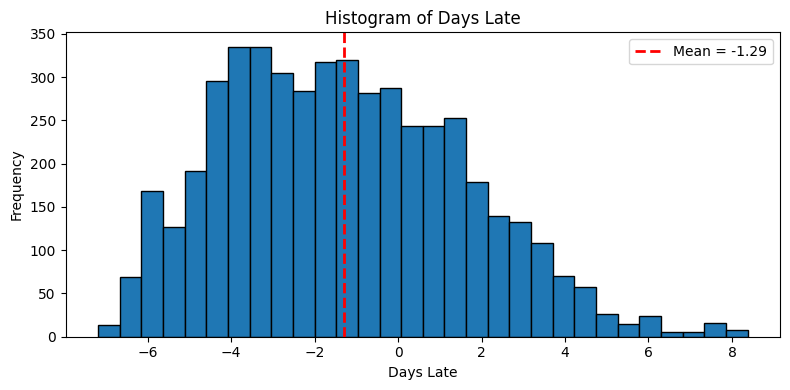

In [28]:

x = rf_test_predictions
m = rf_test_predictions.mean()

plt.figure(figsize=(8, 4))
plt.hist(x, bins=30, edgecolor='black')
plt.axvline(m, color='red', linestyle='--', linewidth=2, label=f"Mean = {m:.2f}")
plt.title('Histogram of Days Late')
plt.xlabel('Days Late')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
X_test['predicted_days_late'] = rf_test_predictions

Add the prediction to the test dataset

In [30]:
X_test['days_late'] = y_test

Compare Prediction and True value

In [31]:
X_test[['predicted_days_late', 'days_late']].head()

,predicted_days_late,days_late
6,-3.400667,-4
8,-0.154703,-1
9,1.539411,-1
14,1.904137,1
16,-5.522250,-7


1. Scatter Plot (Predicted vs Actual)

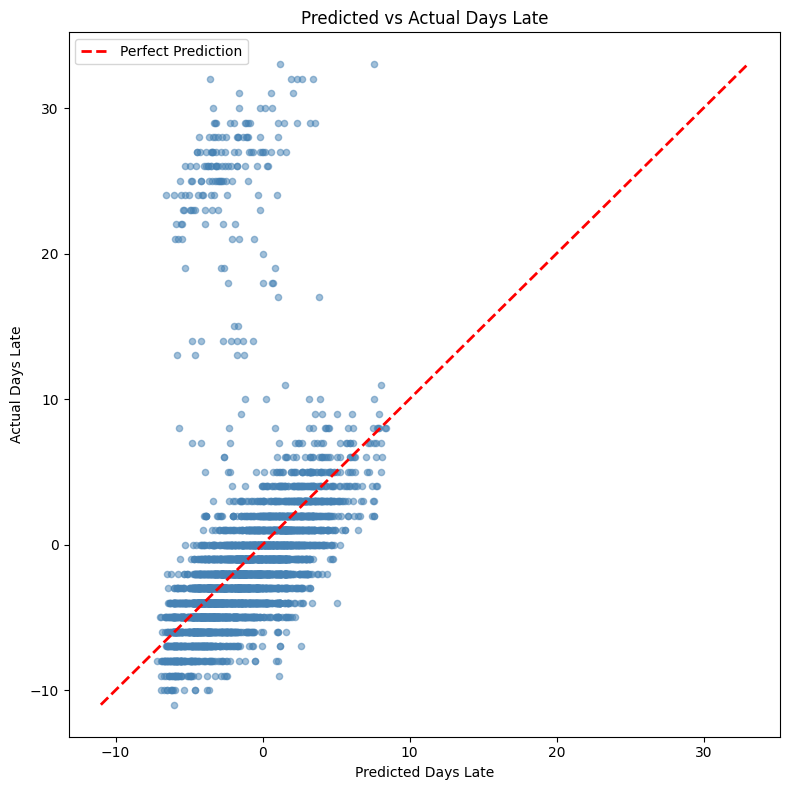

In [33]:

plt.figure(figsize=(8, 8))
plt.scatter(X_test['predicted_days_late'], X_test['days_late'], 
            alpha=0.5, s=20, color='steelblue')

# Perfect prediction line (diagonal)
min_val = min(X_test['predicted_days_late'].min(), X_test['days_late'].min())
max_val = max(X_test['predicted_days_late'].max(), X_test['days_late'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Predicted Days Late')
plt.ylabel('Actual Days Late')
plt.title('Predicted vs Actual Days Late')
plt.legend()
plt.tight_layout()
plt.show()

2. Residual Plot (Error vs Predicted)

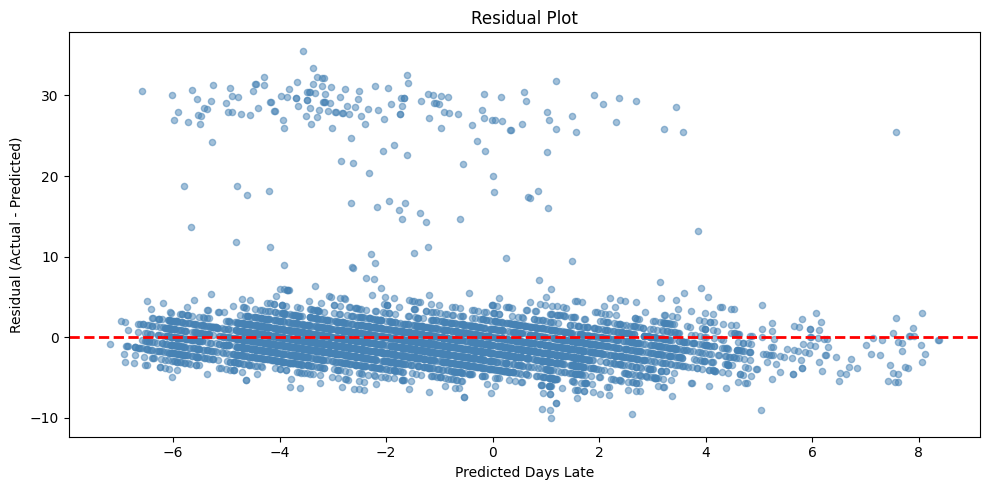

In [34]:
residuals = X_test['days_late'] - X_test['predicted_days_late']

plt.figure(figsize=(10, 5))
plt.scatter(X_test['predicted_days_late'], residuals, alpha=0.5, s=20, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Days Late')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()